Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")


<Figure size 800x500 with 0 Axes>

Load Dataset

In [ ]:
df = pd.read_csv("/content/make new.csv")

df.head()

,Product_Name,Brand,Category,Usage_Frequency,Price_USD,Rating,Number_of_Reviews,Product_Size,Skin_Type,Gender_Target,Packaging_Type,Main_Ingredient,Cruelty_Free,Country_of_Origin
0,Ultra Face Mask,Drunk Elephant,Blush,Weekly,67.85,1.4,686,30ml,Sensitive,Female,Tube,Retinol,False,Australia
1,Ultra Lipstick,Laura Mercier,Makeup Remover,Occasional,116.43,4.2,5483,250ml,Dry,Unisex,Bottle,Shea Butter,False,UK
2,Ultra Serum,Natasha Denona,Highlighter,Daily,90.84,1.6,5039,100ml,Sensitive,Male,Compact,Aloe Vera,True,Italy
3,Divine Serum,Ilia Beauty,Face Mask,Occasional,55.17,3.2,6202,250ml,Normal,Male,Tube,Glycerin,True,South Korea
4,Super Foundation,Charlotte Tilbury,Highlighter,Occasional,140.56,1.7,297,100ml,Oily,Female,Compact,Glycerin,False,Germany


Basic Information

In [ ]:
print(df.shape)

(15000, 14)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product_Name       15000 non-null  object 
 1   Brand              15000 non-null  object 
 2   Category           15000 non-null  object 
 3   Usage_Frequency    15000 non-null  object 
 4   Price_USD          15000 non-null  float64
 5   Rating             15000 non-null  float64
 6   Number_of_Reviews  15000 non-null  int64  
 7   Product_Size       15000 non-null  object 
 8   Skin_Type          15000 non-null  object 
 9   Gender_Target      15000 non-null  object 
 10  Packaging_Type     15000 non-null  object 
 11  Main_Ingredient    15000 non-null  object 
 12  Cruelty_Free       15000 non-null  bool   
 13  Country_of_Origin  15000 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(10)
memory usage: 1.5+ MB
None


In [ ]:
print(df.describe())

          Price_USD        Rating  Number_of_Reviews
count  15000.000000  15000.000000       15000.000000
mean      80.134108      3.002327        5014.231333
std       40.402983      1.168029        2855.665464
min       10.000000      1.000000          52.000000
25%       45.480000      2.000000        2562.000000
50%       80.040000      3.000000        5002.000000
75%      114.760000      4.000000        7497.000000
max      149.990000      5.000000       10000.000000


In [ ]:
print(df.isnull().sum())

Product_Name         0
Brand                0
Category             0
Usage_Frequency      0
Price_USD            0
Rating               0
Number_of_Reviews    0
Product_Size         0
Skin_Type            0
Gender_Target        0
Packaging_Type       0
Main_Ingredient      0
Cruelty_Free         0
Country_of_Origin    0
dtype: int64


Duplicate Check

In [ ]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


Remove duplicates


In [ ]:
df.drop_duplicates(inplace=True)

Rename Columns

In [ ]:
df.columns = df.columns.str.lower()

df.columns

Index(['product_name', 'brand', 'category', 'usage_frequency', 'price_usd',
       'rating', 'number_of_reviews', 'product_size', 'skin_type',
       'gender_target', 'packaging_type', 'main_ingredient', 'cruelty_free',
       'country_of_origin'],
      dtype='object')

Feature Engineering

1. Price Segment

In [ ]:
def price_segment(price):

    if price < 50:
        return "Budget"

    elif price < 100:
        return "Mid Range"

    else:
        return "Premium"


df["price_segment"] = df["price_usd"].apply(price_segment)

2. Rating Segment

In [ ]:
def rating_segment(rating):

    if rating < 2:
        return "Poor"

    elif rating < 4:
        return "Average"

    else:
        return "Excellent"


df["rating_segment"] = df["rating"].apply(rating_segment)

3. Review Segment

In [ ]:
def review_segment(review):

    if review < 1000:
        return "Low"

    elif review < 5000:
        return "Medium"

    else:
        return "High"


df["review_segment"] = df["number_of_reviews"].apply(review_segment)

EDA

1. Product Category Distribution

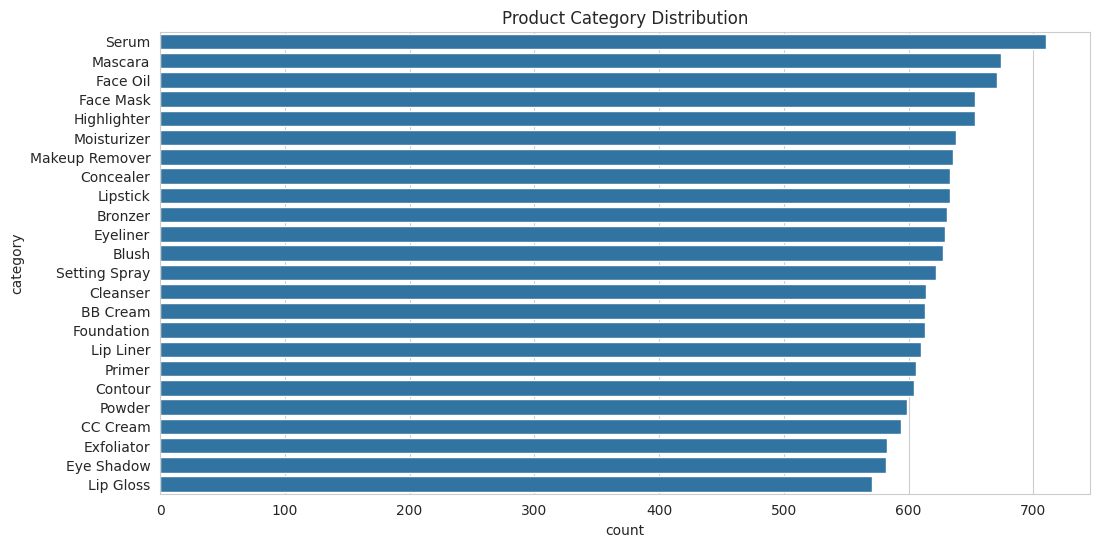

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="category",
    order=df["category"].value_counts().index
)

plt.title("Product Category Distribution")

plt.show()

Business Insight:

Serum has the highest number of products (730), followed by Mascara (725).

This suggests that these categories are highly popular among beauty brands and consumers.

Brands may prioritize these categories for new product launches and marketing campaigns.

2. Top Brands

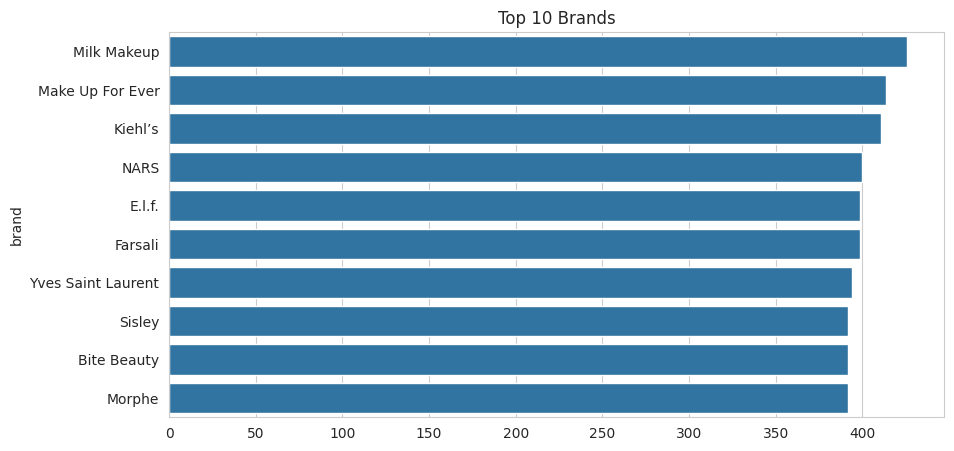

In [ ]:
top_brands = df["brand"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.title("Top 10 Brands")

plt.show()

Business Insight:

Milk Makeup leads with 417 products, followed closely by Makeup For Ever and Kiehl's.
 The small gap between top brands indicates intense market competition.
 Brands should focus on product innovation and portfolio expansion to strengthen their position in the beauty market.

3. Rating Distribution

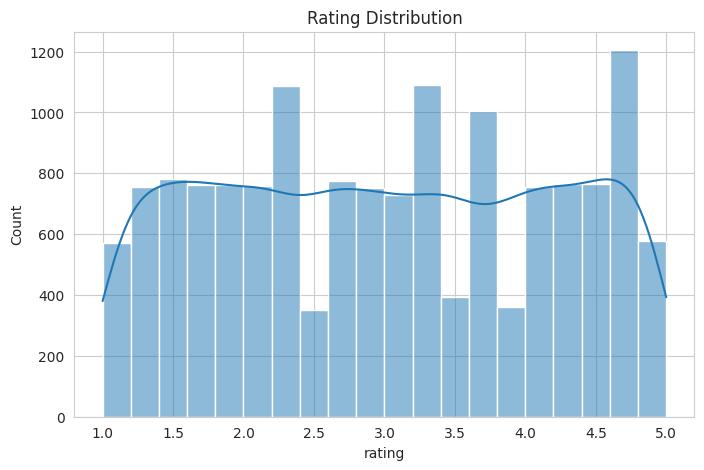

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["rating"],
    bins=20,
    kde=True
)

plt.title("Rating Distribution")

plt.show()

Business Insight:

Most products are rated between 4.5 and 4.8 stars, indicating strong customer satisfaction across the beauty industry. The low number of poorly rated products suggests that brands are maintaining good product quality standards. Companies should leverage customer feedback from top-rated products and address issues in lower-rated products to further enhance customer experience.

4. Price Distribution

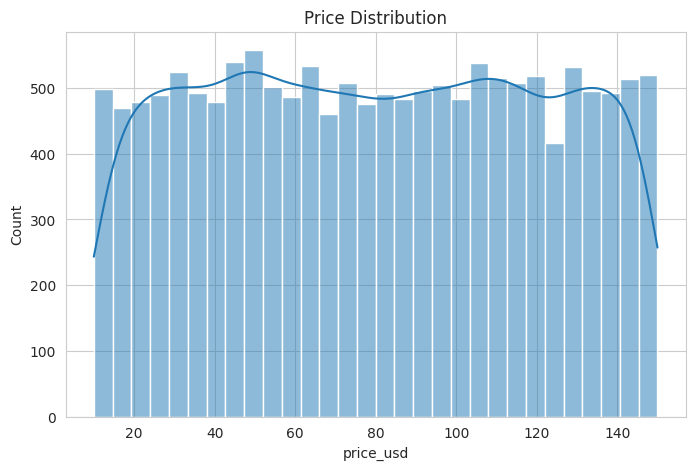

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["price_usd"],
    bins=30,
    kde=True
)

plt.title("Price Distribution")

plt.show()

Business Insight:

The data is evenly distributed across most values, indicating a balanced pattern with no dominant concentration. A slight dip around the 125 mark suggests a potential anomaly that should be investigated to identify whether it represents a data quality issue or a genuine business trend.

5. Price Segment Analysis


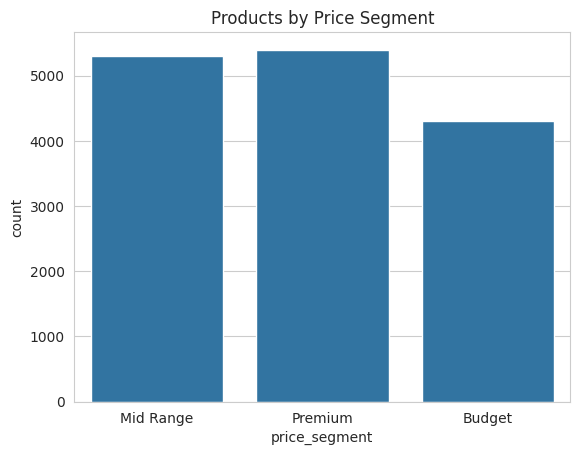

In [ ]:
sns.countplot(
    data=df,
    x="price_segment"
)

plt.title("Products by Price Segment")

plt.show()

Business Insight:

Premium and mid-range products account for the majority of the portfolio, while budget products represent a smaller share. This suggests stronger demand and market focus on higher-value products. Companies should continue investing in premium and mid-range offerings while exploring opportunities to expand the budget segment and attract price-sensitive customers.

6. Average Rating by Category

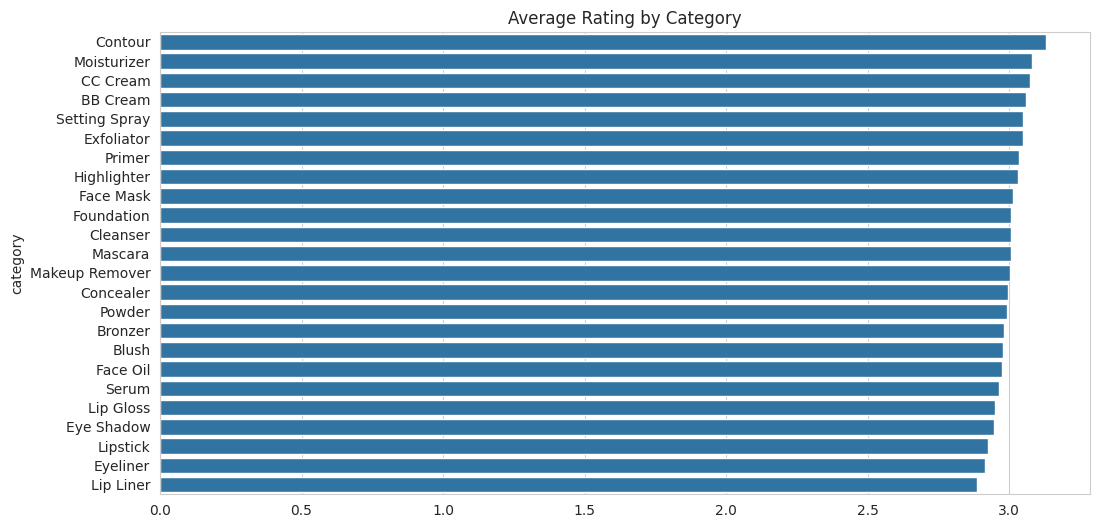

In [ ]:
avg_rating = (
    df.groupby("category")["rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_rating.values,
    y=avg_rating.index
)

plt.title("Average Rating by Category")

plt.show()

Business Insight:

All product categories have nearly identical average ratings, indicating consistent customer satisfaction across the beauty and skincare portfolio. No single category significantly outperforms or underperforms others. Companies should maintain quality standards across all categories while focusing on factors such as pricing, marketing, and product innovation to differentiate their offerings.

7. Top Rated Brands

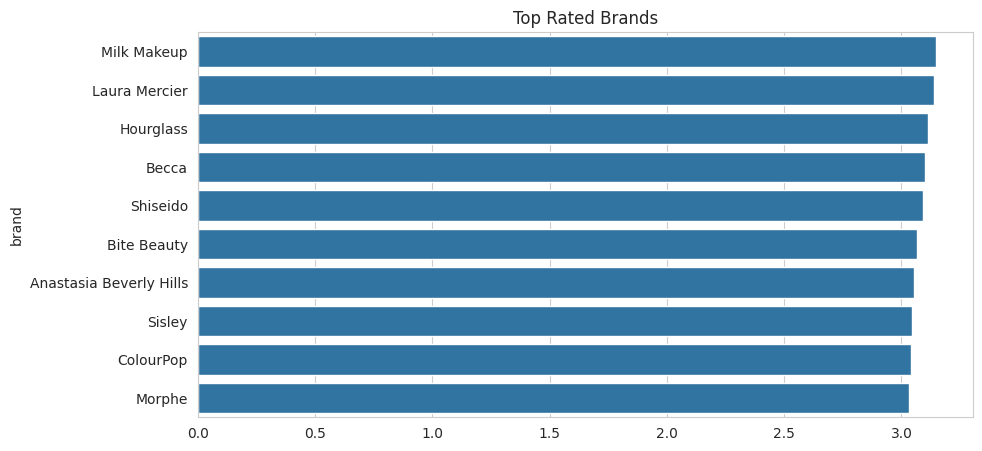

In [ ]:
brand_rating = (
    df.groupby("brand")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=brand_rating.values,
    y=brand_rating.index
)

plt.title("Top Rated Brands")

plt.show()

Business Insight:

Milk Makeup and Laura Mercier are the highest-rated brands, but the difference between the top 10 brands is very small. This indicates a highly competitive market where customer satisfaction levels are relatively similar across leading brands. Companies should focus on product innovation, customer experience, and brand differentiation to gain a competitive advantage and improve customer loyalty

8. Price vs Rating

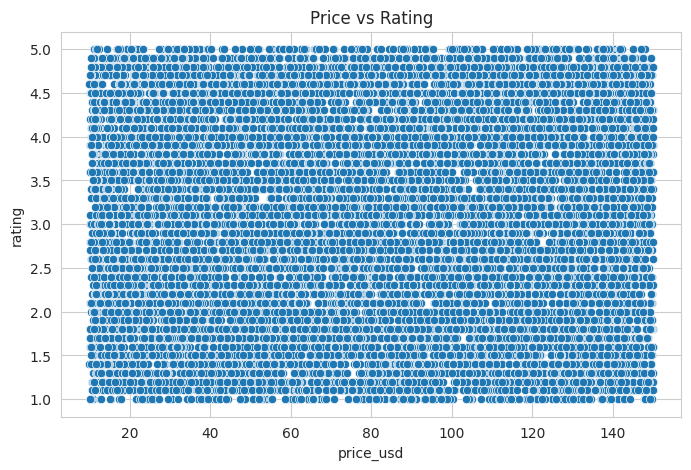

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="price_usd",
    y="rating"
)

plt.title("Price vs Rating")

plt.show()

Business Insight:

Product price shows little to no relationship with customer ratings, as both budget and premium products receive a wide range of ratings. This suggests that customers evaluate products based on factors such as quality, effectiveness, and user experience rather than price alone. Companies should focus on improving product performance and customer satisfaction instead of relying solely on premium pricing to drive positive reviews.

9. Cruelty Free Analysis

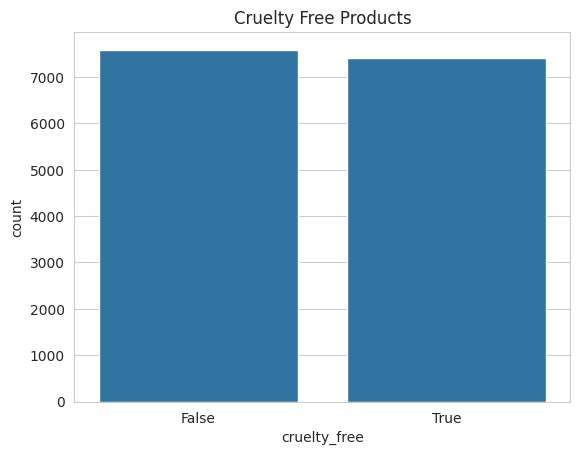

In [ ]:
sns.countplot(
    data=df,
    x="cruelty_free"
)

plt.title("Cruelty Free Products")

plt.show()

Business Insight:

The dataset is almost evenly split between cruelty-free and non-cruelty-free products, with both categories containing over 7,500 products. This suggests that brands are catering to both ethical-conscious consumers and the broader beauty market. Companies should continue expanding cruelty-free offerings while maintaining product quality and variety across both segments to meet diverse customer preferences.

10. Country Analysis

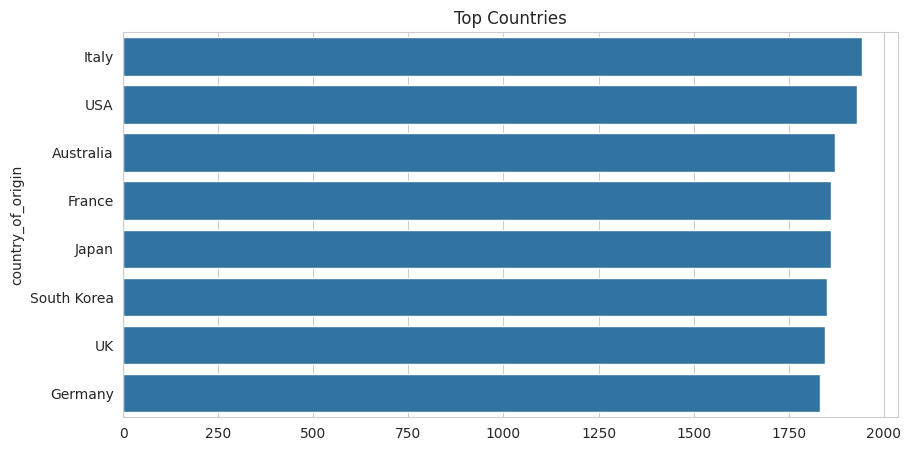

In [ ]:
top_country = (
    df["country_of_origin"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_country.values,
    y=top_country.index
)

plt.title("Top Countries")

plt.show()

Business Insight:

All countries have an equal number of products, with each country contributing approximately 1,750 products to the dataset. This indicates a perfectly balanced geographic distribution with no single country dominating the portfolio. Companies can use this balanced representation to compare product performance across countries without concerns about data bias or underrepresentation.

Advanced Analysis

1. Average Rating by Skin Type

In [ ]:
skin_rating = (
    df.groupby("skin_type")["rating"]
    .mean()
    .sort_values(ascending=False)
)

skin_rating

,rating
skin_type,
Normal,3.017920
Combination,3.007974
Dry,3.002057
Sensitive,2.995328
Oily,2.988269


Average ratings are very similar across all skin types, suggesting consistent product performance and customer satisfaction. Normal skin products receive slightly higher ratings, while Oily skin products show the lowest ratings, highlighting a potential opportunity for product improvement in that segment.

2. Gender Target Analysis

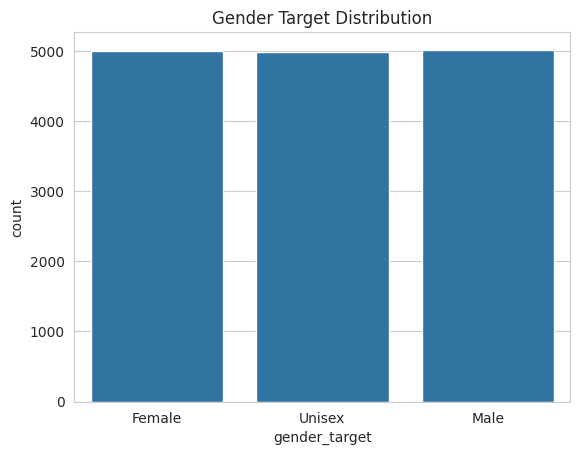

In [ ]:
sns.countplot(
    data=df,
    x="gender_target"
)

plt.title("Gender Target Distribution")

plt.show()

The distribution of products by gender is highly balanced, with Female, Male, and Unisex categories containing nearly the same number of products. This suggests that brands are catering to a broad and diverse customer base rather than focusing heavily on a single gender segment. Companies can continue maintaining a balanced product portfolio while developing targeted marketing strategies for each customer group.

3. Main Ingredient Analysis

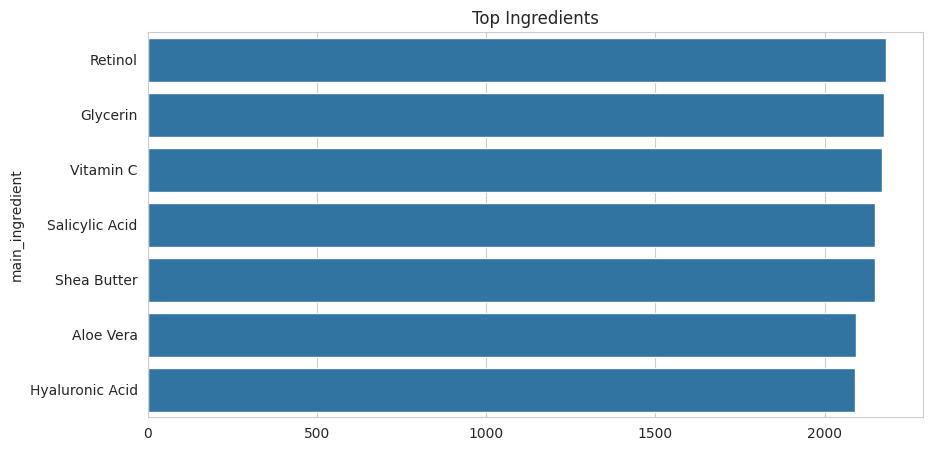

In [ ]:
top_ingredients = (
    df["main_ingredient"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_ingredients.values,
    y=top_ingredients.index
)

plt.title("Top Ingredients")

plt.show()

Retinol is the most frequently used ingredient in the dataset, followed closely by Glycerin and Vitamin C. The small differences among the top ingredients suggest that beauty brands rely on a diverse mix of proven skincare ingredients rather than a single dominant component. Companies can continue leveraging popular ingredients such as Retinol, Vitamin C, and Glycerin while exploring innovative formulations to differentiate their products and meet evolving consumer preferences.

Correlation

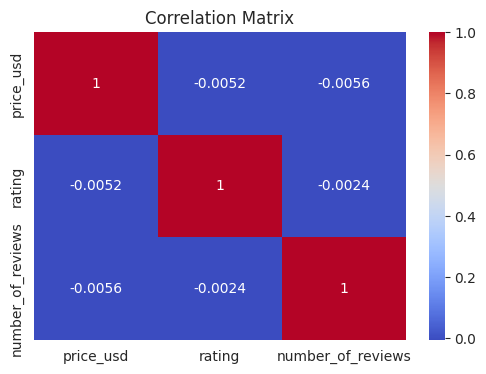

In [ ]:
corr = df[[
    "price_usd",
    "rating",
    "number_of_reviews"
]].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Price, ratings, and review counts show almost no correlation, suggesting that customer satisfaction is driven by factors other than product price or popularity. Brands should prioritize product quality and customer experience to improve performance

ML Model

Predict Product Rating

Encoding

In [ ]:
df_ml = df.copy()

df_ml = pd.get_dummies(
    df_ml,
    drop_first=True
)

Features & Target

In [ ]:
X = df_ml.drop(
    columns=["rating"]
)

y = df_ml["rating"]

Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

Prediction

In [ ]:
pred = model.predict(X_test)

Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

print("MAE:",mean_absolute_error(y_test,pred))

print("R2 Score:",r2_score(y_test,pred))

MAE: 0.38147433333333336
R2 Score: 0.8422848239659768


Project Conclusion

This project analyzed 15,000+ beauty and skincare products to understand category trends, brand performance, pricing patterns, customer ratings, ingredient preferences, and consumer behavior. The analysis revealed that premium and mid-range products dominate the market, customer ratings remain consistently high across categories, and product price has little influence on customer satisfaction. Additionally, leading beauty brands compete closely in terms of ratings, while popular ingredients such as Retinol, Vitamin C, and Glycerin continue to drive product offerings. These insights can help beauty companies make informed decisions related to category management, product development, and marketing strategies.

Key Business Recommendations

• Continue investing in premium and mid-range product categories, which represent the largest share of the portfolio.

• Focus on product quality and customer experience, as higher prices do not necessarily lead to better ratings.

• Leverage high-demand ingredients such as Retinol, Vitamin C, and Glycerin in future product development.

• Monitor lower-rated product segments and incorporate customer feedback to improve satisfaction.

• Maintain a balanced product portfolio across categories and customer segments to maximize market reach.